## **Read data and Imports**

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=3000)]
    )

2026-04-22 15:15:21.539611: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-22 15:15:21.539735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-22 15:15:21.550310: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 15:15:21.590222: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 15:15:22.933353: W tensorflow/compiler/tf2

In [2]:
import pandas as pd
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skrebate import ReliefF
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os
import random
import cv2
import sklearn
from sklearn.feature_selection import (
    mutual_info_regression,  # Information Gain
    chi2,                    # Chi-square Test
    f_classif,               # ANOVA (F-test)
    SelectKBest,             # Select top k features
    VarianceThreshold        # Variance Threshold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


Total images: 13015


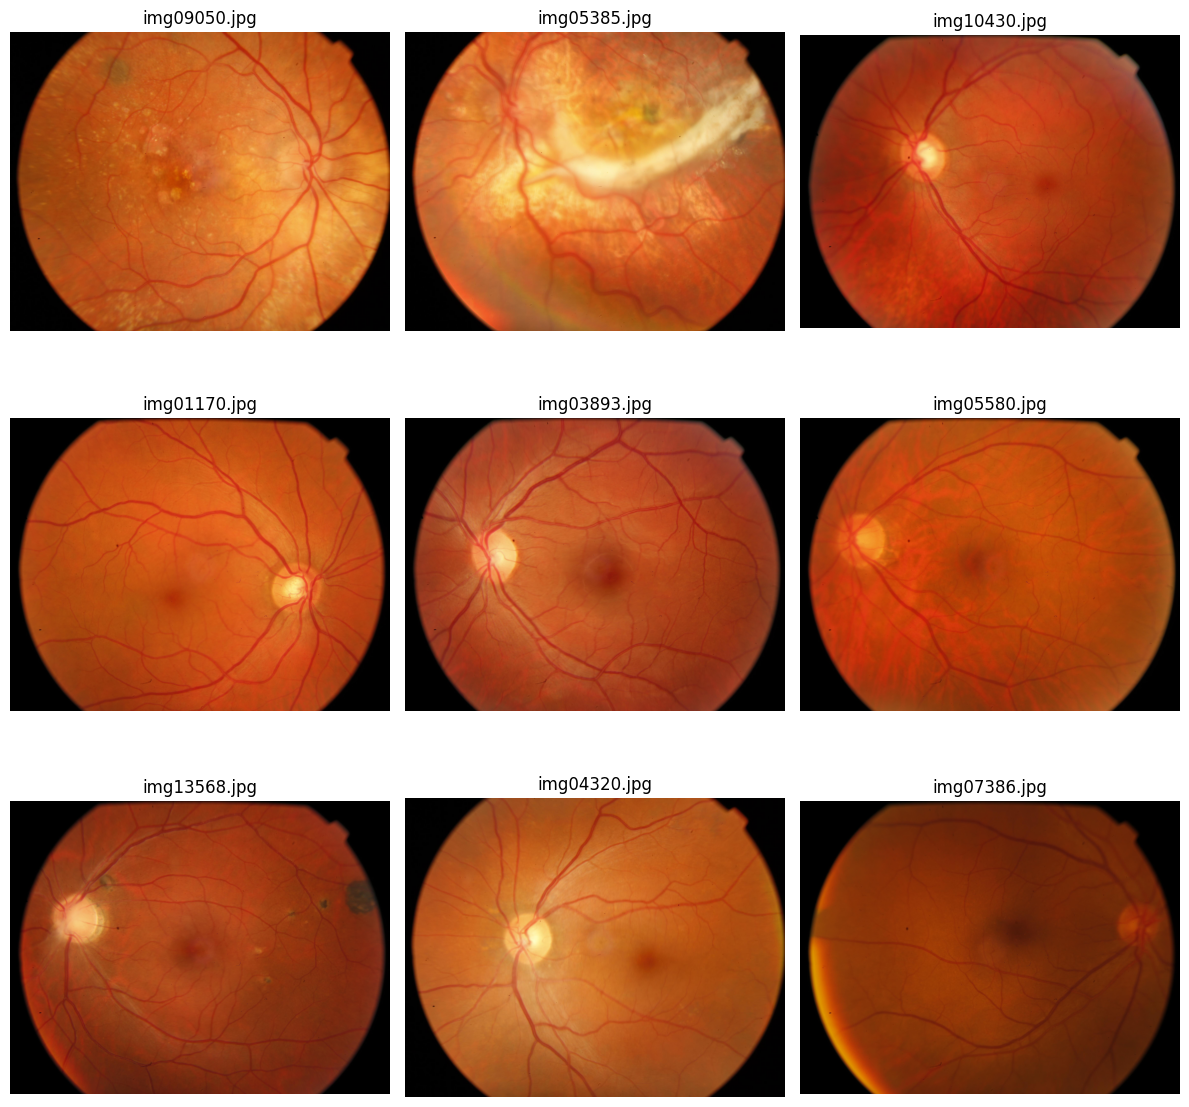

In [3]:
folder = "../../Data/dataset_split/train/images"
image_paths = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total images:", len(image_paths))

sample_paths = random.sample(image_paths, 9)

plt.figure(figsize=(12, 12))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(os.path.basename(path))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
sizes = []

for path in sample_paths:
    img = cv2.imread(path)
    h, w = img.shape[:2]
    sizes.append((h, w))
    print(os.path.basename(path), "->", (h, w))

img09050.jpg -> (1880, 2390)
img05385.jpg -> (1880, 2390)
img10430.jpg -> (2304, 2984)
img01170.jpg -> (2304, 2984)
img03893.jpg -> (2304, 2984)
img05580.jpg -> (2304, 2984)
img13568.jpg -> (2304, 2984)
img04320.jpg -> (1880, 2390)
img07386.jpg -> (2304, 2984)


## **Preprocessing**

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) CROP
# =========================
def crop_black_borders(img, threshold=20):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    coords = np.argwhere(mask)
    if coords.size == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img[y0:y1, x0:x1]


# =========================
# 2) GREEN CHANNEL
# =========================
def extract_green_channel(img):
    return img[:, :, 1]


# =========================
# 3) CLAHE
# =========================
def apply_clahe_gray(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(img)


# =========================
# 4) FULL PIPELINE D (NO ILLUMINATION)
# =========================
def preprocess_pipeline_d(
    path,
    target_size=(224, 224),
    threshold=20,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    normalize_mode="01"
):

    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    # RGB
    original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ORIGINAL SIZE
    print("Original image shape:", original.shape)

    # 1) crop
    cropped = crop_black_borders(original, threshold=threshold)
    print("After crop shape:", cropped.shape)

    # 2) resize
    resized = cv2.resize(cropped, target_size)
    print("After resize shape:", resized.shape)

    # 3) green channel
    green = extract_green_channel(resized)
    print("Green channel shape:", green.shape)

    # 4) CLAHE
    green_clahe = apply_clahe_gray(
        green,
        clip_limit=clip_limit,
        tile_grid_size=tile_grid_size
    )
    print("After CLAHE shape:", green_clahe.shape)

    # 5) normalize
    processed = green_clahe.astype(np.float32)

    if normalize_mode == "01":
        processed = processed / 255.0
    elif normalize_mode == "neg1":
        processed = (processed / 127.5) - 1.0
    else:
        raise ValueError("normalize_mode must be '01' or 'neg1'")

    # BEFORE stacking
    print("Before stacking shape:", processed.shape)

    # stack to 3 channels
    processed = np.stack([processed]*3, axis=-1)

    # AFTER stacking
    print("After stacking shape:", processed.shape)

    return {
        "original": original,
        "cropped": cropped,
        "resized": resized,
        "green": green,
        "clahe": green_clahe,
        "processed": processed
    }


# =========================
# 5) VISUALIZATION
# =========================
def visualize_pipeline_d(path):
    out = preprocess_pipeline_d(path)

    titles = ["original", "cropped", "resized", "green", "clahe", "processed"]

    plt.figure(figsize=(16, 8))

    for i, key in enumerate(titles):
        plt.subplot(2, 3, i + 1)
        img = out[key]

        if key in ["green", "clahe", "processed"]:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)

        plt.title(key)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Original image shape: (1880, 2390, 3)
After crop shape: (1880, 2353, 3)
After resize shape: (224, 224, 3)
Green channel shape: (224, 224)
After CLAHE shape: (224, 224)
Before stacking shape: (224, 224)
After stacking shape: (224, 224, 3)


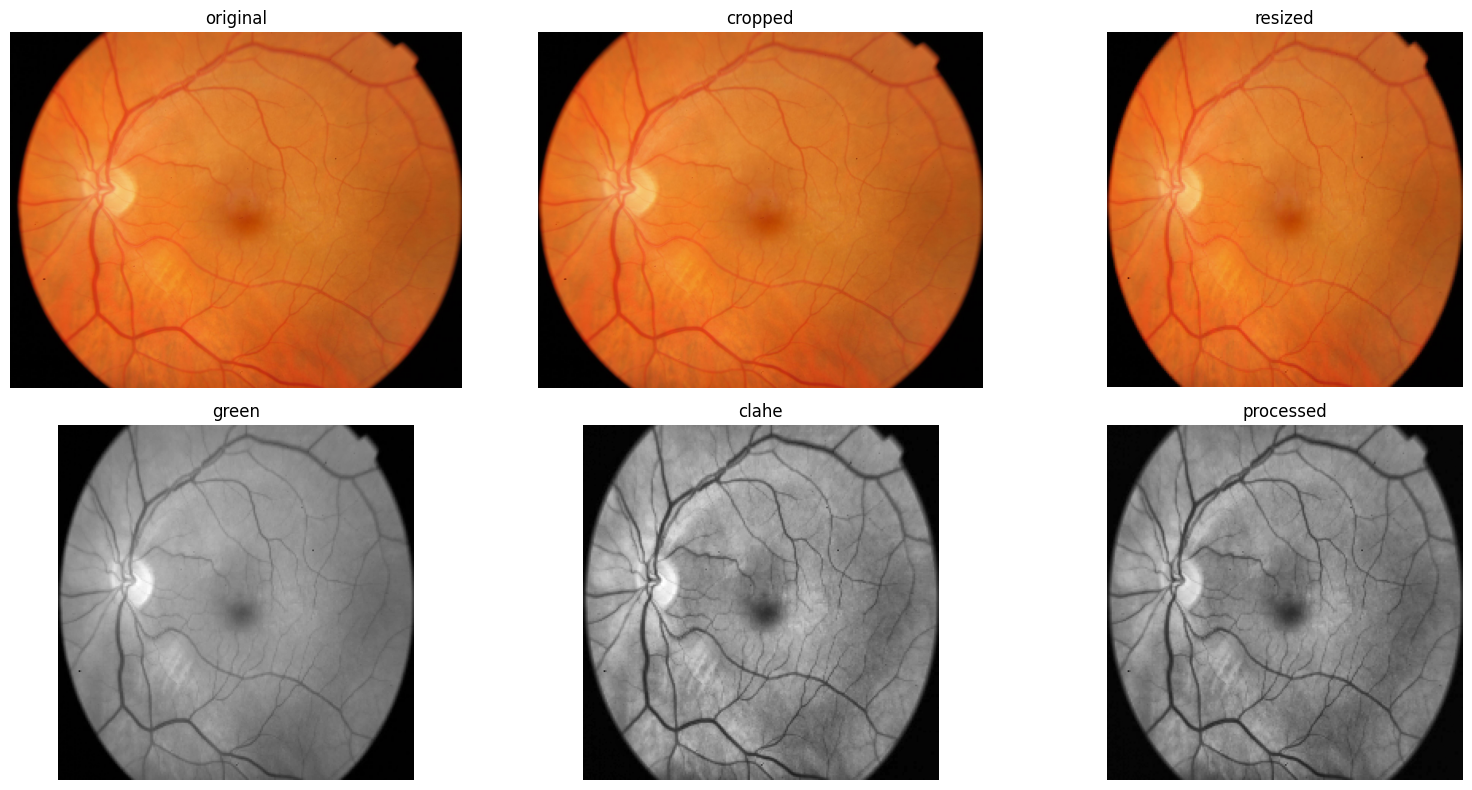

In [7]:
path = image_paths[5005]
visualize_pipeline_d(path)

In [1]:
PROCESSED_TRAIN_DIR = "../../Data/dataset_split/train/images_processed"
PROCESSED_VAL_DIR   = "../../Data/dataset_split/val/images_processed"
PROCESSED_TEST_DIR  = "../../Data/dataset_split/test/images_processed"

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = (224, 224)

def crop_black_borders(img, threshold=20):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    coords = np.argwhere(mask)
    if coords.size == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def extract_green_channel(img):
    return img[:, :, 1]

def apply_clahe_gray(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(img)

def preprocess_and_save_image(
    input_path,
    output_path,
    target_size=(224, 224),
    threshold=20,
    clip_limit=2.0,
    tile_grid_size=(8, 8)
):
    img_bgr = cv2.imread(input_path)
    if img_bgr is None:
        return False

    # BGR -> RGB
    original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # crop
    cropped = crop_black_borders(original, threshold=threshold)

    # resize
    resized = cv2.resize(cropped, target_size)

    # green channel
    green = extract_green_channel(resized)

    # CLAHE
    green_clahe = apply_clahe_gray(
        green,
        clip_limit=clip_limit,
        tile_grid_size=tile_grid_size
    )

    # stack back to 3 channels
    processed = np.stack([green_clahe] * 3, axis=-1)   # uint8 shape (224,224,3)

    # save as PNG
    processed_bgr = cv2.cvtColor(processed, cv2.COLOR_RGB2BGR)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, processed_bgr)

    return True

In [3]:
def preprocess_folder(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    valid_exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    files = [f for f in os.listdir(input_dir) if os.path.splitext(f)[1] in valid_exts]

    success_count = 0
    fail_count = 0

    for fname in tqdm(files, desc=f"Processing {input_dir}"):
        input_path = os.path.join(input_dir, fname)

        # always save as png
        stem = os.path.splitext(fname)[0]
        output_path = os.path.join(output_dir, stem + ".png")

        ok = preprocess_and_save_image(input_path, output_path, target_size=IMG_SIZE)

        if ok:
            success_count += 1
        else:
            fail_count += 1
            print(f"Failed: {input_path}")

    print(f"\nDone: {input_dir}")
    print("Saved:", success_count)
    print("Failed:", fail_count)

In [4]:
TRAIN_IMAGE_DIR = "../../Data/dataset_split/train/images"
VAL_IMAGE_DIR   = "../../Data/dataset_split/val/images"
TEST_IMAGE_DIR  = "../../Data/dataset_split/test/images"

PROCESSED_TRAIN_DIR = "../../Data/dataset_split/train/images_processed"
PROCESSED_VAL_DIR   = "../../Data/dataset_split/val/images_processed"
PROCESSED_TEST_DIR  = "../../Data/dataset_split/test/images_processed"

preprocess_folder(TRAIN_IMAGE_DIR, PROCESSED_TRAIN_DIR)
preprocess_folder(VAL_IMAGE_DIR, PROCESSED_VAL_DIR)
preprocess_folder(TEST_IMAGE_DIR, PROCESSED_TEST_DIR)

Processing ../../Data/dataset_split/train/images: 100%|██████████| 13015/13015 [27:06<00:00,  8.00it/s]



Done: ../../Data/dataset_split/train/images
Saved: 13015
Failed: 0


Processing ../../Data/dataset_split/val/images: 100%|██████████| 1632/1632 [03:18<00:00,  8.23it/s]



Done: ../../Data/dataset_split/val/images
Saved: 1632
Failed: 0


Processing ../../Data/dataset_split/test/images: 100%|██████████| 1619/1619 [03:14<00:00,  8.31it/s]


Done: ../../Data/dataset_split/test/images
Saved: 1619
Failed: 0
